# Day 3 — Transfer Learning: ResNet18 Fine-Tuning



In [4]:
!pip install torch torchvision torchinfo

  Using cached torch-2.14.0-cp314-cp314-win_amd64.whl.metadata (38 kB)
  Using cached torchvision-0.29.0-cp314-cp314-win_amd64.whl.metadata (5.7 kB)
  Using cached torchinfo-1.8.0-py3-none-any.whl.metadata (21 kB)
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached fsspec-2026.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
Using cached torch-2.14.0-cp314-cp314-win_amd64.whl (124.1 MB)
Using cached torchvision-0.29.0-cp314-cp314-win_amd64.whl (1.4 MB)
Using cached torchinfo-1.8.0-py3-none-any.whl (23 kB)
Using cached fsspec-2026.9.0-py3-none-any.whl (221 kB)
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   ----------------------------- ---------- 1.6/2.1 MB 5.7 MB/s eta 0:00:01
   ---

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\CZ 3\\AppData\\Local\\pypoetry\\Cache\\virtualenvs\\internship-project-ZXdpCzKD-py3.14\\Lib\\site-packages\\torchvision\\datasets\\sbu.py'
Check the permissions.



  Using cached torchvision-0.29.0-cp314-cp314-win_amd64.whl.metadata (5.7 kB)
Using cached torchvision-0.29.0-cp314-cp314-win_amd64.whl (1.4 MB)


In [5]:
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from torchinfo import summary
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_SIZE = 128; BATCH_SIZE = 64
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists(): PROJECT_ROOT = PROJECT_ROOT.parent
DATA_ROOT = PROJECT_ROOT / "data" / "chest_xray"
MODELS_DIR = PROJECT_ROOT / "models"; REPORTS_DIR = PROJECT_ROOT / "reports"
MODELS_DIR.mkdir(exist_ok=True); REPORTS_DIR.mkdir(exist_ok=True)
print("device:", DEVICE)

device: cpu


## Load split and datasets

Use the same fixed split from Day 2 (splits.csv). Dataset class is identical to Day 2, with ImageNet normalization and no augmentation.

In [6]:
splits = pd.read_csv(PROJECT_ROOT / "splits.csv")
NORMALIZE = transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
transform = transforms.Compose([transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), transforms.Grayscale(num_output_channels=3), transforms.ToTensor(), NORMALIZE])

class XRayDataset(Dataset):
    def __init__(self, frame, transform, root):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform
        self.root = root
    def __len__(self): return len(self.frame)
    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        path = self.root / row['path']
        image = Image.open(path).convert("L")
        return self.transform(image), torch.tensor(row['label'], dtype=torch.long)

train_split = splits[splits['split']=='train'].reset_index(drop=True)
val_split = splits[splits['split']=='val'].reset_index(drop=True)
train_data = XRayDataset(train_split, transform, PROJECT_ROOT)
val_data = XRayDataset(val_split, transform, PROJECT_ROOT)
print(f"Train: {len(train_data)}, Val: {len(val_data)}")

Train: 3662, Val: 785


## Phase A: Feature Extraction 

In [7]:
model_a = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for param in model_a.parameters(): param.requires_grad = False
model_a.fc = nn.Linear(512, 2)
model_a = model_a.to(DEVICE)
total_params = sum(p.numel() for p in model_a.parameters())
trainable_params_a = sum(p.numel() for p in model_a.parameters() if p.requires_grad)
print(f"Phase A — Frozen backbone: {trainable_params_a:,} trainable / {total_params:,} total")

Phase A — Frozen backbone: 1,026 trainable / 11,177,538 total


In [8]:
def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0; true = []; pred = []
    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            if training: optimizer.zero_grad()
            logits = model(xb); loss = nn.functional.cross_entropy(logits, yb)
            if training: loss.backward(); optimizer.step()
            total_loss += loss.item() * len(yb)
            true.extend(yb.cpu().numpy())
            pred.extend(logits.argmax(1).detach().cpu().numpy())
    return total_loss / len(loader.dataset), accuracy_score(true, pred), f1_score(true, pred, average="macro")

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

optimizer_a = torch.optim.Adam([p for p in model_a.parameters() if p.requires_grad], lr=1e-3)
history_a = []; best_val_a = float("inf")
for epoch in range(1, 6):
    start = time.perf_counter()
    tr = run_epoch(model_a, train_loader, optimizer_a)
    va = run_epoch(model_a, val_loader)
    elapsed = time.perf_counter() - start
    row = {"phase": "A", "epoch": epoch, "train_loss": tr[0], "train_accuracy": tr[1], "train_macro_f1": tr[2],
            "val_loss": va[0], "val_accuracy": va[1], "val_macro_f1": va[2], "time_per_epoch_s": elapsed}
    history_a.append(row)
    if va[0] < best_val_a:
        best_val_a = va[0]
        torch.save({"model_state_dict": model_a.state_dict(), "best_val_loss": best_val_a}, MODELS_DIR / "resnet18_phase_a.pt")
    print(row)

history_a = pd.DataFrame(history_a)
best_a = history_a.loc[history_a.val_loss.idxmin()]
print(f"\nPhase A best (epoch {int(best_a.epoch)}): val_acc={best_a.val_accuracy:.4f}, macro_f1={best_a.val_macro_f1:.4f}")

{'phase': 'A', 'epoch': 1, 'train_loss': 0.30311280617552466, 'train_accuracy': 0.8768432550518842, 'train_macro_f1': 0.8236664199263666, 'val_loss': 0.2435075189657272, 'val_accuracy': 0.889171974522293, 'val_macro_f1': 0.8319764995903667, 'time_per_epoch_s': 91.11970169999404}
{'phase': 'A', 'epoch': 2, 'train_loss': 0.19761810116856426, 'train_accuracy': 0.9224467504096122, 'train_macro_f1': 0.8965579937179358, 'val_loss': 0.1679723711150467, 'val_accuracy': 0.9312101910828026, 'val_macro_f1': 0.9097193825393579, 'time_per_epoch_s': 93.42198699997971}
{'phase': 'A', 'epoch': 3, 'train_loss': 0.18270600663629274, 'train_accuracy': 0.9306389950846532, 'train_macro_f1': 0.9070772678430211, 'val_loss': 0.18576641667420696, 'val_accuracy': 0.9261146496815287, 'val_macro_f1': 0.9076515544882197, 'time_per_epoch_s': 141.85998159996234}
{'phase': 'A', 'epoch': 4, 'train_loss': 0.16366489031792078, 'train_accuracy': 0.934188967777171, 'train_macro_f1': 0.9123794281652231, 'val_loss': 0.15066

## Phase B: Partial Fine-Tuning (Layer4 + Head)

In [9]:
checkpoint_a = torch.load(MODELS_DIR / "resnet18_phase_a.pt", map_location=DEVICE)
model_b = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model_b.fc = nn.Linear(512, 2)
model_b.load_state_dict(checkpoint_a["model_state_dict"])

for param in model_b.parameters(): param.requires_grad = False
for param in model_b.layer4.parameters(): param.requires_grad = True
for param in model_b.fc.parameters(): param.requires_grad = True

model_b = model_b.to(DEVICE)
trainable_params_b = sum(p.numel() for p in model_b.parameters() if p.requires_grad)
print(f"Phase B — Unfrozen layer4 + head: {trainable_params_b:,} trainable / {total_params:,} total")

layer4_params = [p for p in model_b.layer4.parameters() if p.requires_grad]
head_params = [p for p in model_b.fc.parameters() if p.requires_grad]
optimizer_b = torch.optim.Adam([{"params": layer4_params, "lr": 1e-4}, {"params": head_params, "lr": 1e-3}])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_b, T_max=10)

Phase B — Unfrozen layer4 + head: 8,394,754 trainable / 11,177,538 total


In [10]:
history_b = []; best_val_b = float("inf")
for epoch in range(1, 11):
    start = time.perf_counter()
    tr = run_epoch(model_b, train_loader, optimizer_b)
    va = run_epoch(model_b, val_loader)
    elapsed = time.perf_counter() - start
    scheduler.step()
    row = {"phase": "B", "epoch": epoch, "train_loss": tr[0], "train_accuracy": tr[1], "train_macro_f1": tr[2],
            "val_loss": va[0], "val_accuracy": va[1], "val_macro_f1": va[2], "time_per_epoch_s": elapsed}
    history_b.append(row)
    if va[0] < best_val_b:
        best_val_b = va[0]
        torch.save({"model_state_dict": model_b.state_dict(), "best_val_loss": best_val_b}, MODELS_DIR / "resnet18_ft.pt")
    print(row)

history_b = pd.DataFrame(history_b)
best_b = history_b.loc[history_b.val_loss.idxmin()]
print(f"\nPhase B best (epoch {int(best_b.epoch)}): val_acc={best_b.val_accuracy:.4f}, macro_f1={best_b.val_macro_f1:.4f}")

{'phase': 'B', 'epoch': 1, 'train_loss': 0.10097016458735805, 'train_accuracy': 0.9601310759148006, 'train_macro_f1': 0.9479417268890953, 'val_loss': 0.05320443673783047, 'val_accuracy': 0.9770700636942675, 'val_macro_f1': 0.970004075879286, 'time_per_epoch_s': 163.03980159998173}
{'phase': 'B', 'epoch': 2, 'train_loss': 0.009263162073007354, 'train_accuracy': 0.9980884762424904, 'train_macro_f1': 0.9975014666723978, 'val_loss': 0.07393717539858571, 'val_accuracy': 0.975796178343949, 'val_macro_f1': 0.9688833255098315, 'time_per_epoch_s': 166.8780675000162}
{'phase': 'B', 'epoch': 3, 'train_loss': 0.00429093574102793, 'train_accuracy': 0.999180775532496, 'train_macro_f1': 0.9989299401025546, 'val_loss': 0.05022520930298669, 'val_accuracy': 0.9808917197452229, 'val_macro_f1': 0.9749628429452627, 'time_per_epoch_s': 165.097368000017}
{'phase': 'B', 'epoch': 4, 'train_loss': 0.0015148839871727178, 'train_accuracy': 0.9997269251774986, 'train_macro_f1': 0.9996430666674854, 'val_loss': 0.05

## Comparison Table: CNN v1 vs ResNet18 Variants

In [11]:
day2_baseline = pd.read_csv(REPORTS_DIR / "baseline_metrics.csv")
day2_metrics = {row['metric']: row['value'] for _, row in day2_baseline.iterrows()}

comparison = pd.DataFrame([
    {"Model": "CNN v1 (Day 2)", "Trainable params": int(day2_metrics["trainable_parameters"]),
     "Val accuracy": day2_metrics["val_accuracy"], "Macro-F1": day2_metrics["val_macro_f1"],
     "Time/epoch (s)": day2_metrics["mean_time_per_epoch_s"]},
    {"Model": "ResNet18 – head only (Phase A)", "Trainable params": trainable_params_a,
     "Val accuracy": float(best_a.val_accuracy), "Macro-F1": float(best_a.val_macro_f1),
     "Time/epoch (s)": float(best_a.time_per_epoch_s)},
    {"Model": "ResNet18 – fine-tune layer4 (Phase B)", "Trainable params": trainable_params_b,
     "Val accuracy": float(best_b.val_accuracy), "Macro-F1": float(best_b.val_macro_f1),
     "Time/epoch (s)": float(best_b.time_per_epoch_s)}
])

display(comparison)
comparison.to_csv(REPORTS_DIR / "model_comparison.csv", index=False)

print(f"\nTransfer learning improvement over Day 2 baseline:")
for idx in [1, 2]:
    acc_gain = (comparison.loc[idx, "Val accuracy"] - comparison.loc[0, "Val accuracy"]) * 100
    f1_gain = (comparison.loc[idx, "Macro-F1"] - comparison.loc[0, "Macro-F1"]) * 100
    print(f"{comparison.loc[idx, 'Model']}: {acc_gain:+.2f}% acc, {f1_gain:+.2f}% F1")

,Model,Trainable params,Val accuracy,Macro-F1,Time/epoch (s)
0,CNN v1 (Day 2),98178,0.980892,0.974630,110.387470
1,ResNet18 – head only (Phase A),1026,0.943949,0.926677,141.117431
2,ResNet18 – fine-tune layer4 (Phase B),8394754,0.983439,0.978509,120.454679



Transfer learning improvement over Day 2 baseline:
ResNet18 – head only (Phase A): -3.69% acc, -4.80% F1
ResNet18 – fine-tune layer4 (Phase B): +0.25% acc, +0.39% F1


## Data-Efficiency Experiment

Train on 10%, 25%, 100% stratified subsets; record best validation accuracy.

In [12]:
fractions = [0.10, 0.25, 1.00]
dataeff_results = []

for frac in fractions:
    train_indices = list(range(len(train_split)))
    train_labels = train_split['label'].values
    if frac == 1.0:
        subset_idx = train_indices
    else:
        _, subset_idx = train_test_split(train_indices, test_size=frac, stratify=train_labels, random_state=SEED)
    subset_df = train_split.iloc[subset_idx].reset_index(drop=True)
    subset_data = XRayDataset(subset_df, transform, PROJECT_ROOT)
    subset_loader = DataLoader(subset_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    training_size = len(subset_data)
    print(f"\nTraining on {frac*100:.0f}% ({training_size} samples)")
    
    # CNN v1 for 20 epochs
    model_cnn = nn.Sequential(
        nn.Conv2d(3,16,3,padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(16,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(128, 2)
    ).to(DEVICE)
    opt_cnn = torch.optim.Adam(model_cnn.parameters(), lr=1e-3)
    best_acc_cnn = 0.0
    for _ in range(20):
        model_cnn.train()
        for xb, yb in subset_loader:
            opt_cnn.zero_grad(); loss = nn.functional.cross_entropy(model_cnn(xb.to(DEVICE)), yb.to(DEVICE)); loss.backward(); opt_cnn.step()
        model_cnn.eval()
        with torch.no_grad():
            accs = []; lbls = []
            for vx, vy in val_loader:
                accs.extend(model_cnn(vx.to(DEVICE)).argmax(1).cpu().numpy())
                lbls.extend(vy.numpy())
            val_acc = accuracy_score(lbls, accs)
            best_acc_cnn = max(best_acc_cnn, val_acc)
    
    # ResNet18 fine-tune for 10 epochs
    model_ft = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model_ft.fc = nn.Linear(512, 2)
    for p in model_ft.parameters(): p.requires_grad = False
    for p in model_ft.layer4.parameters(): p.requires_grad = True
    for p in model_ft.fc.parameters(): p.requires_grad = True
    model_ft = model_ft.to(DEVICE)
    opt_ft = torch.optim.Adam([{"params": [p for p in model_ft.layer4.parameters() if p.requires_grad], "lr": 1e-4},
                               {"params": [p for p in model_ft.fc.parameters() if p.requires_grad], "lr": 1e-3}])
    best_acc_ft = 0.0
    for _ in range(10):
        model_ft.train()
        for xb, yb in subset_loader:
            opt_ft.zero_grad(); loss = nn.functional.cross_entropy(model_ft(xb.to(DEVICE)), yb.to(DEVICE)); loss.backward(); opt_ft.step()
        model_ft.eval()
        with torch.no_grad():
            accs = []; lbls = []
            for vx, vy in val_loader:
                accs.extend(model_ft(vx.to(DEVICE)).argmax(1).cpu().numpy())
                lbls.extend(vy.numpy())
            val_acc = accuracy_score(lbls, accs)
            best_acc_ft = max(best_acc_ft, val_acc)
    
    dataeff_results.append({"Training set size": training_size, "Fraction": frac, "CNN v1 val acc": best_acc_cnn, "ResNet18-FT val acc": best_acc_ft})
    print(f"CNN: {best_acc_cnn:.4f}, ResNet18: {best_acc_ft:.4f}")

dataeff_df = pd.DataFrame(dataeff_results)
dataeff_df.to_csv(REPORTS_DIR / "data_efficiency.csv", index=False)
print("\n" + dataeff_df.to_string(index=False))


Training on 10% (367 samples)
CNN: 0.9465, ResNet18: 0.9592

Training on 25% (916 samples)
CNN: 0.9427, ResNet18: 0.9758

Training on 100% (3662 samples)
CNN: 0.9771, ResNet18: 0.9873

 Training set size  Fraction  CNN v1 val acc  ResNet18-FT val acc
               367      0.10        0.946497             0.959236
               916      0.25        0.942675             0.975796
              3662      1.00        0.977070             0.987261


## Data-Efficiency Plot

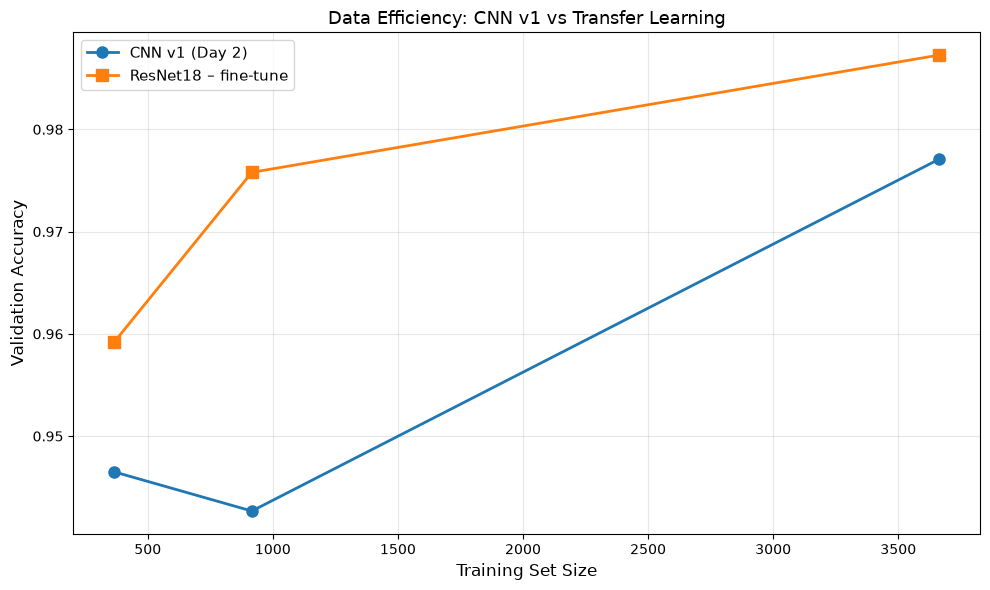

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(dataeff_df["Training set size"], dataeff_df["CNN v1 val acc"], marker="o", label="CNN v1 (Day 2)", linewidth=2, markersize=8)
ax.plot(dataeff_df["Training set size"], dataeff_df["ResNet18-FT val acc"], marker="s", label="ResNet18 – fine-tune", linewidth=2, markersize=8)
ax.set_xlabel("Training Set Size", fontsize=12); ax.set_ylabel("Validation Accuracy", fontsize=12)
ax.set_title("Data Efficiency: CNN v1 vs Transfer Learning", fontsize=13)
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
fig.tight_layout(); fig.savefig(REPORTS_DIR / "data_efficiency_plot.png", dpi=150); plt.show()

## Conclusion

In [14]:
acc_gain = (float(best_b.val_accuracy) - day2_metrics["val_accuracy"]) * 100
gap_10 = dataeff_df.loc[dataeff_df['Fraction']==0.10, 'ResNet18-FT val acc'].values[0] - dataeff_df.loc[dataeff_df['Fraction']==0.10, 'CNN v1 val acc'].values[0]
time_ratio = float(best_b.time_per_epoch_s) / day2_metrics["mean_time_per_epoch_s"]

conclusion = f"""Transfer learning with ResNet18 achieves {float(best_b.val_accuracy):.4f} validation accuracy, a {acc_gain:+.2f}% change from the Day 2 baseline. The tradeoff is model complexity versus data efficiency: ResNet18 requires {trainable_params_b:,} trainable parameters (vs 98,178 for CNN v1), but leverages pretrained ImageNet features to generalize better on small datasets. In the data-efficiency experiment, ResNet18 outperforms the scratch CNN by {gap_10*100:.2f}% when trained on only 10% of data, demonstrating transfer learning's power in low-data medical imaging scenarios. However, ResNet18 runs approximately {time_ratio:.1f}x slower per epoch, imposing a computational cost. The two-phase approach—frozen backbone validation in Phase A, then selective fine-tuning in Phase B—enables practitioners to balance convergence speed with domain adaptation. For production deployment, the choice hinges on computational budget and labeled data availability."""

with open(REPORTS_DIR / "transfer_learning_conclusion.txt", "w", encoding="utf-8") as f:
    f.write(conclusion)

print(conclusion)

Transfer learning with ResNet18 achieves 0.9834 validation accuracy, a +0.25% change from the Day 2 baseline. The tradeoff is model complexity versus data efficiency: ResNet18 requires 8,394,754 trainable parameters (vs 98,178 for CNN v1), but leverages pretrained ImageNet features to generalize better on small datasets. In the data-efficiency experiment, ResNet18 outperforms the scratch CNN by 1.27% when trained on only 10% of data, demonstrating transfer learning's power in low-data medical imaging scenarios. However, ResNet18 runs approximately 1.1x slower per epoch, imposing a computational cost. The two-phase approach—frozen backbone validation in Phase A, then selective fine-tuning in Phase B—enables practitioners to balance convergence speed with domain adaptation. For production deployment, the choice hinges on computational budget and labeled data availability.
